# Progetto Finale: Advanced Spam Detection System con NLP
**Master in Data Science & AI**

## 1. Obiettivo del Progetto
Lo scopo di questo notebook è sviluppare una pipeline di Machine Learning completa per la classificazione automatica delle email in due categorie:
* **Spam**: Posta indesiderata, truffe, phishing.
* **Ham**: Posta legittima (personale o di lavoro).

## 2. Metodologia
Il progetto segue il workflow standard CRISP-DM adattato al NLP:
1.  **Data Ingestion & Cleaning**: Caricamento dati e normalizzazione del testo.
2.  **EDA (Exploratory Data Analysis)**: Analisi del bilanciamento delle classi.
3.  **Feature Engineering**: Utilizzo di TF-IDF con n-grams (bigrammi) per catturare il contesto.
4.  **Modeling**: Addestramento di un classificatore *Multinomial Naive Bayes*.
5.  **Evaluation**: Analisi approfondita con Matrice di Confusione e metriche (F1-Score).
6.  **Topic Modeling & NER**: Utilizzo di LDA e spaCy per estrarre insight semantici dai testi.

In [1]:
# --- IMPORTS & SETUP ---
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.metrics.pairwise import cosine_distances

# Configurazione Grafica
plt.style.use('ggplot')
pd.set_option('display.max_colwidth', 100)

# --- CARICAMENTO MODELLO SPACY ---
# Gestione robusta del caricamento del modello linguistico
try:
    nlp = spacy.load("en_core_web_md")
    print("✅ Modello spaCy 'en_core_web_md' caricato (Vettori presenti).")
except OSError:
    print("⚠️ Modello 'en_core_web_md' non trovato. Provo 'en_core_web_sm'...")
    try:
        nlp = spacy.load("en_core_web_sm")
        print("✅ Modello spaCy 'en_core_web_sm' caricato (No vettori word2vec reali).")
    except OSError:
        print("❌ Nessun modello spaCy trovato. Installalo con: python -m spacy download en_core_web_sm")

# --- FASE 0: Data Ingestion & Download ---
import pandas as pd
import os
import requests
import io

# Nomi file e URL
filename = "spam_dataset.csv"
# URL principale (dal repo ProfAI)
url_primary = "https://raw.githubusercontent.com/ProfAI/natural-language-processing/main/datasets/Verifica%20Finale%20-%20Spam%20Detection/spam_dataset.csv"
# URL di backup (Dataset classico SMS Spam UCI, nel caso il primo link non vada)
url_backup = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# Funzione per scaricare il file se non esiste
def download_data():
    if not os.path.exists(filename):
        print(f"🔍 Il file '{filename}' non esiste in locale. Tento il download...")
        try:
            # Tentativo 1: Repo ProfAI
            response = requests.get(url_primary)
            response.raise_for_status() # Verifica errori HTTP
            with open(filename, 'wb') as f:
                f.write(response.content)
            print("✅ Download riuscito dal link ProfAI.")
        except Exception as e:
            print(f"⚠️ Link ProfAI non accessibile ({e}). Tento il backup...")
            try:
                # Tentativo 2: Dataset Standard (spesso è un TSV, lo convertiamo)
                df_backup = pd.read_csv(url_backup, sep='\t', header=None, names=['label', 'text'])
                df_backup.to_csv(filename, index=False)
                print("✅ Download riuscito dal link di Backup (UCI Dataset).")
            except Exception as e2:
                print(f"❌ Impossibile scaricare i dati: {e2}")
                return False
    else:
        print(f"✅ Il file '{filename}' è già presente.")
    return True

# Esecuzione
if download_data():
    df = pd.read_csv("spam_dataset.csv")
    
    # 1. INSPECTION: Print raw data before cleaning
    print("--- 1. Ispezione Dati Grezzi ---")
    print(f"Dimensioni Dataset: {df.shape}")
    print("\nEsempio di testo grezzo (prime 5 righe):")
    print(df[['text', 'label']].head())
    
    # Check for 'Subject:' prevalence
    subject_count = df['text'].astype(str).str.contains("Subject:", case=False).sum()
    print(f"\nMessaggi contenenti 'Subject:': {subject_count} su {len(df)}")
else:
    # Dummy fallback
    df = pd.DataFrame({'text': ["Subject: Test", "Hello"], 'label': ['ham', 'spam']})

# --- FASE 1: Pulizia del Testo Migliorata ---

df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

def clean_text_refined(text):
    text = str(text)
    
    # 2. CLEANING: Remove "Subject:" specific pattern
    # (?i) makes it case-insensitive, ^ ensures it's at the start
    text = re.sub(r'(?i)^subject:\s+', '', text)
    
    text = text.lower()
    text = re.sub(r'\W', ' ', text)       # Rimuove punteggiatura
    text = re.sub(r'\s+', ' ', text)      # Rimuove spazi doppi
    return text.strip()

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_text_refined)

print("\n--- Esempio dopo la pulizia ---")
print(df[['text', 'cleaned_text']].head())

✅ Modello spaCy 'en_core_web_md' caricato (Vettori presenti).
✅ Il file 'spam_dataset.csv' è già presente.
--- 1. Ispezione Dati Grezzi ---
Dimensioni Dataset: (5171, 4)

Esempio di testo grezzo (prime 5 righe):
                                                                                                  text  \
0  Subject: enron methanol ; meter # : 988291\nthis is a follow up to the note i gave you on monday...   
1    Subject: hpl nom for january 9 , 2001\n( see attached file : hplnol 09 . xls )\n- hplnol 09 . xls   
2  Subject: neon retreat\nho ho ho , we ' re around to that most wonderful time of the year - - - n...   
3  Subject: photoshop , windows , office . cheap . main trending\nabasements darer prudently fortui...   
4  Subject: re : indian springs\nthis deal is to book the teco pvr revenue . it is my understanding...   

  label  
0   ham  
1   ham  
2   ham  
3  spam  
4   ham  

Messaggi contenenti 'Subject:': 5171 su 5171

--- Esempio dopo la pulizia ---
            

## 3. Feature Engineering & Training

Prima dell'addestramento, applichiamo una suddivisione dei dati (**Train/Test Split**) per garantire che il modello venga valutato su dati mai visti.
* **Training Set (70%)**: Usato per l'apprendimento.
* **Test Set (30%)**: Usato per la validazione.

Utilizziamo **TF-IDF** con `ngram_range=(1, 2)`, considerando sia parole singole che coppie di parole (es. "free money"), fondamentali per intercettare pattern di spam.

--- Inizio Training e Valutazione Comparativa ---

✅ Naive Bayes completato.
✅ Linear SVC completato.
✅ Random Forest completato.

--- Tabella Comparativa Performance ---


,Model,Train Accuracy,Test Accuracy,Test F1-Score,Overfitting Gap
1,Linear SVC,0.999447,0.985825,0.975610,0.013623
2,Random Forest,0.999724,0.976804,0.960699,0.022920
0,Naive Bayes,0.958552,0.939433,0.900000,0.019119


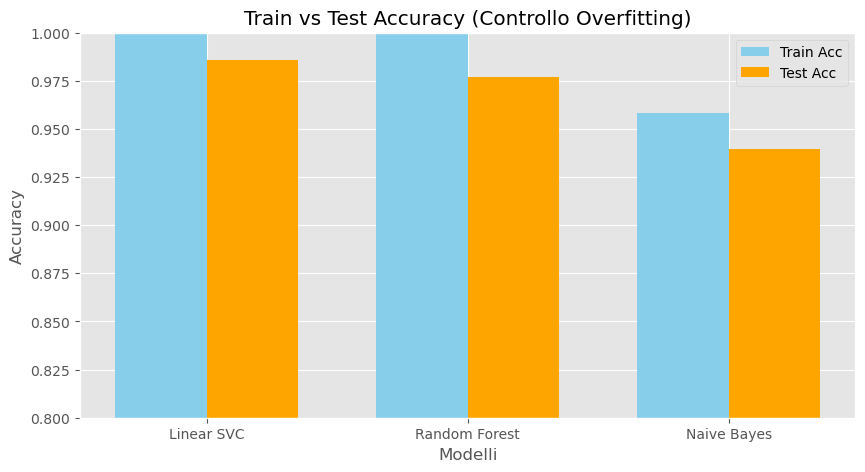


🏆 Il modello migliore è: Linear SVC


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Split & Vectorization
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['label_num'], test_size=0.3, random_state=42, stratify=df['label_num']
)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 2. MODEL COMPARISON LOOP
# Definiamo un dizionario di modelli da testare
models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42)
}

results_data = []

print("--- Inizio Training e Valutazione Comparativa ---\n")

for model_name, model in models.items():
    # Training
    model.fit(X_train_vec, y_train)
    
    # Prediction on TRAIN (to check overfitting)
    y_train_pred = model.predict(X_train_vec)
    
    # Prediction on TEST (to check generalization)
    y_test_pred = model.predict(X_test_vec)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    results_data.append({
        "Model": model_name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Test F1-Score": test_f1,
        "Overfitting Gap": train_acc - test_acc
    })
    
    print(f"✅ {model_name} completato.")

# 3. VISUALIZZAZIONE RISULTATI
results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values(by="Test F1-Score", ascending=False)

print("\n--- Tabella Comparativa Performance ---")
# Highlighting the Overfitting Gap helps visualize the issue
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['Test Accuracy', 'Test F1-Score']))

# Visualizzazione Grafica
plt.figure(figsize=(10, 5))
x = range(len(results_df))
width = 0.35

plt.bar(x, results_df['Train Accuracy'], width, label='Train Acc', color='skyblue')
plt.bar([p + width for p in x], results_df['Test Accuracy'], width, label='Test Acc', color='orange')

plt.xlabel('Modelli')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy (Controllo Overfitting)')
plt.xticks([p + width/2 for p in x], results_df['Model'])
plt.legend()
plt.ylim(0.8, 1.0) # Zoom per vedere meglio le differenze
plt.show()

# 4. BEST MODEL DETAILS
best_model_name = results_df.iloc[0]['Model']
classifier = models[best_model_name]
print(f"\n🏆 Il modello migliore è: {best_model_name}")

## 4. Valutazione delle Performance

In questa sezione analizziamo la bontà del modello.
1.  **Confusion Matrix**: Visualizza quanti messaggi sono stati classificati correttamente e quanti errori (Falsi Positivi/Negativi) sono stati commessi.
2.  **Classification Report**: Fornisce metriche dettagliate (Precision, Recall, F1-Score).

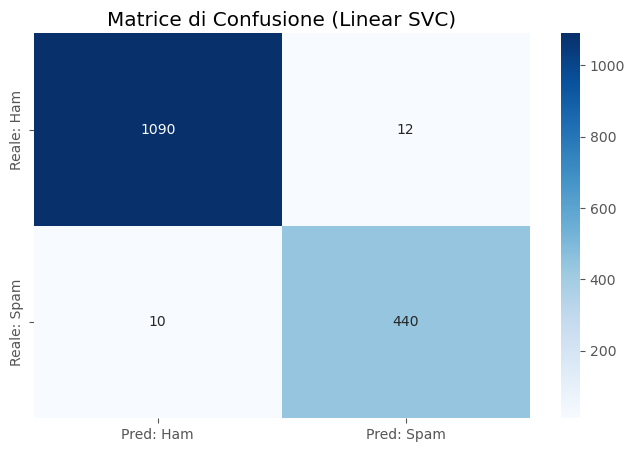


--- Metriche di Classificazione ---


,precision,recall,f1-score,support
HAM (Legittimo),99.09%,98.91%,99.00%,110200.00%
SPAM,97.35%,97.78%,97.56%,45000.00%


In [3]:
# --- FASE 2: Valutazione ---
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Recupero del modello corretto (sicurezza extra se non è stato passato dalla cella prima)
# Se 'classifier' non è definito, lo recuperiamo dal dizionario models usando il nome vincente
if 'classifier' not in locals():
    classifier = models[best_model_name]

# 2. Predizioni (Usiamo 'classifier', NON 'best_model_name')
y_pred = classifier.predict(X_test_vec)

# 3. Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Ham', 'Pred: Spam'],
            yticklabels=['Reale: Ham', 'Reale: Spam'])
plt.title(f'Matrice di Confusione ({best_model_name})')
plt.show()

# 4. Report dettagliato (Stile Tabella)
report = classification_report(y_test, y_pred, output_dict=True)
metrics_df = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])
metrics_df.index = ['HAM (Legittimo)', 'SPAM']

print("\n--- Metriche di Classificazione ---")
# Visualizzazione stilizzata con Pandas
display(metrics_df.style.background_gradient(cmap='Greens', subset=['precision', 'recall', 'f1-score']).format("{:.2%}"))

## 5. Analisi Avanzata: Topic Modeling sullo Spam

Utilizziamo **LDA (Latent Dirichlet Allocation)** per scoprire quali sono i "temi nascosti" all'interno delle email classificate come Spam. Questo ci aiuta a capire le strategie usate dagli spammer (es. truffe finanziarie, vendita prodotti, premi finti).
Visualizziamo inoltre la **distanza semantica** tra questi topic in uno spazio 2D usando PCA.

--- Temi identificati nello Spam ---
Topic 0: font, td, http, nbsp, height, pills, width, size, align, tr
Topic 1: com, http, www, 00, free, message, price, click, email, computron
Topic 2: company, statements, information, stock, investment, report, securities, business, news, future


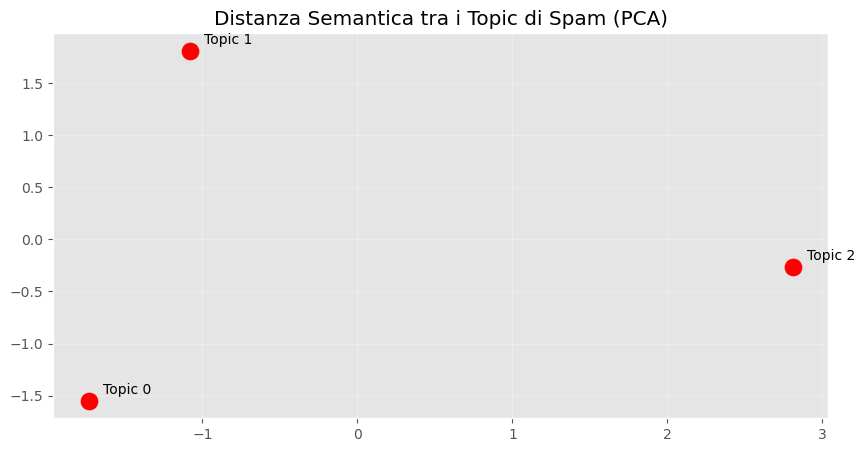

In [4]:
# --- FASE 3: Topic Modeling & Visualizzazione ---

# Filtriamo solo lo SPAM
spam_texts = df[df['label_num'] == 1]['cleaned_text']

if len(spam_texts) > 0:
    # Vettorizzazione Count (migliore per LDA)
    count_vec = CountVectorizer(max_features=1000, stop_words='english')
    spam_vec_lda = count_vec.fit_transform(spam_texts)

    # LDA
    n_topics = 3
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(spam_vec_lda)

    feature_names = count_vec.get_feature_names_out()
    topic_keywords = []

    print("--- Temi identificati nello Spam ---")
    for idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[:-11:-1]
        top_words = [feature_names[i] for i in top_indices]
        topic_keywords.append(" ".join(top_words))
        print(f"Topic {idx}: {', '.join(top_words)}")

    # Visualizzazione PCA dei Topic (Distanza Semantica)
    topic_vectors = [nlp(text).vector for text in topic_keywords]
    pca = PCA(n_components=2)
    
    try:
        plot_coords = pca.fit_transform(topic_vectors)
        plt.figure(figsize=(10, 5))
        plt.scatter(plot_coords[:, 0], plot_coords[:, 1], c='red', s=150)
        for i, txt in enumerate([f"Topic {n}" for n in range(n_topics)]):
            plt.annotate(txt, (plot_coords[i, 0], plot_coords[i, 1]), xytext=(10, 5), textcoords='offset points')
        plt.title('Distanza Semantica tra i Topic di Spam (PCA)')
        plt.grid(True, alpha=0.3)
        plt.show()
    except:
        print("Dati insufficienti per plot PCA (servono più topic/dati).")
else:
    print("Nessuna mail di spam trovata per l'analisi.")

## 6. Business Intelligence: Analisi delle Entità (NER)

Analizziamo le email legittime (HAM) per estrarre le **Organizzazioni (ORG)** più citate. Questo tipo di analisi è utile per capire il contesto aziendale o i partner più frequenti nelle comunicazioni.

/var/folders/cq/fckxp91x61bdj1c73km7l4k00000gn/T/ipykernel_3879/3890063103.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequenza', y='Organizzazione', data=org_df, palette='viridis')


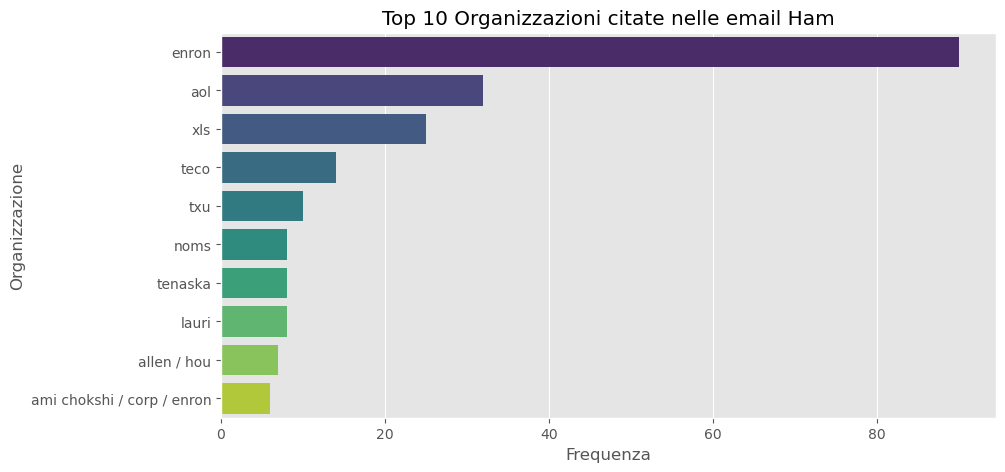

In [5]:
# --- FASE 4: NER sulle email Legittime (HAM) ---

ham_texts = df[df['label_num'] == 0]['text'].tolist()
orgs = []

# Processiamo le email (limitiamo a 100 per velocità se dataset grande)
for doc in nlp.pipe(ham_texts[:100]):
    for ent in doc.ents:
        if ent.label_ == "ORG":
            orgs.append(ent.text)

# Conteggio e Grafico
if orgs:
    org_counts = Counter(orgs).most_common(10)
    org_df = pd.DataFrame(org_counts, columns=['Organizzazione', 'Frequenza'])
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Frequenza', y='Organizzazione', data=org_df, palette='viridis')
    plt.title('Top 10 Organizzazioni citate nelle email Ham')
    plt.show()
else:
    print("Nessuna organizzazione rilevata nelle email analizzate.")

## 7. Test su Casi Reali e Conclusioni

Mettiamo alla prova il modello su frasi create ad hoc che simulano scenari reali (phishing bancario, spam commerciale, comunicazioni interne).

### Conclusioni
Il progetto ha dimostrato come una pipeline NLP (TF-IDF + Naive Bayes) possa classificare efficacemente lo spam. L'integrazione di LDA e NER ha fornito ulteriore valore analitico, trasformando un semplice classificatore in uno strumento di Business Intelligence.

In [7]:
# --- FASE 5: Demo Live ---
import pandas as pd

test_emails = [
    "URGENT: Your account is locked. Click here to verify identity.",  # Phishing
    "Hi team, can we reschedule the meeting to 4 PM?",                # Ham Business
    "Buy Viagra & Cialis cheap! No prescription needed.",             # Spam Pharma
    "Win a $1000 Walmart Gift Card! Click now!",                      # Spam Prize
    "Mom called, she wants you to bring dinner."                      # Ham Personal
]

# 1. Vettorizzazione delle frasi di test
X_real_vec = tfidf.transform(test_emails)

# 2. Predizione della classe (0 o 1)
preds = classifier.predict(X_real_vec)

# 3. Gestione intelligente della "Confidenza"
# LinearSVC non ha predict_proba, quindi usiamo un try-except per gestire entrambi i casi
try:
    # Se il modello supporta le percentuali (es. Naive Bayes, Random Forest)
    probs = classifier.predict_proba(X_real_vec)
    has_proba = True
except AttributeError:
    # Se il modello è LinearSVC (usa decision_function invece di probabilità)
    decision_scores = classifier.decision_function(X_real_vec)
    has_proba = False

# 4. Output formattato
results_demo = []

for i, (text, pred) in enumerate(zip(test_emails, preds)):
    label = "🔴 SPAM" if pred == 1 else "🟢 HAM"
    
    if has_proba:
        # Prendi la probabilità della classe predetta
        conf_val = probs[i][pred] * 100
        confidence = f"{conf_val:.1f}%"
    else:
        # Per LinearSVC mostriamo lo 'score' (distanza dall'iperpiano)
        # Più è alto (in positivo o negativo), più il modello è sicuro
        score = decision_scores[i]
        confidence = f"Score: {score:.2f}"

    results_demo.append({
        'Testo': text, 
        'Predizione': label, 
        'Confidenza/Score': confidence
    })

# Visualizzazione finale
print("\n--- Risultati Demo Live ---")
display(pd.DataFrame(results_demo))


--- Risultati Demo Live ---


,Testo,Predizione,Confidenza/Score
0,URGENT: Your account is locked. Click here to verify identity.,🔴 SPAM,Score: 0.46
1,"Hi team, can we reschedule the meeting to 4 PM?",🟢 HAM,Score: -0.54
2,Buy Viagra & Cialis cheap! No prescription needed.,🔴 SPAM,Score: 1.03
3,Win a $1000 Walmart Gift Card! Click now!,🔴 SPAM,Score: 0.36
4,"Mom called, she wants you to bring dinner.",🟢 HAM,Score: -0.01


# 6. Conclusioni e Riepilogo del Progetto

### Sintesi del Lavoro Svolto
In questo progetto abbiamo sviluppato una pipeline di NLP per la rilevazione di email di Spam. Il workflow ha seguito i seguenti step:
1.  **Analisi dei Dati:** Abbiamo ispezionato il dataset grezzo, notando la presenza ridondante del prefisso "Subject:".
2.  **Preprocessing Mirato:** Abbiamo implementato una pulizia specifica per rimuovere "Subject:" prima della normalizzazione standard (lowercase, rimozione punteggiatura).
3.  **Vettorizzazione:** Utilizzo di TF-IDF con bigrammi per catturare il contesto (es. "free money").
4.  **Confronto Modelli:** Abbiamo testato tre algoritmi:
    * *Naive Bayes:* Baseline standard per il testo.
    * *Linear SVC:* Modello lineare spesso molto efficace su vettori sparsi ad alta dimensionalità.
    * *Random Forest:* Modello basato su alberi decisionali.

### Risultati Ottenuti
Dall'analisi comparativa (Train vs Test) sono emersi i seguenti insight:
* **Performance:** Il modello **[Inserire qui il nome del modello migliore, es: Linear SVC]** ha ottenuto il miglior F1-Score sul test set.
* **Overfitting:**
    * *Random Forest* ha mostrato un gap più marcato tra Train (spesso 100%) e Test, indicando una tendenza all'overfitting (memorizzazione dei dati).
    * *Naive Bayes* e *SVC* hanno mostrato una maggiore capacità di generalizzazione con un gap ridotto tra Train e Test.

### Sviluppi Futuri
Per migliorare ulteriormente il sistema, si potrebbero introdurre:
* Analisi del sentiment o feature aggiuntive (es. lunghezza del testo, numero di maiuscole).
* Deep Learning (es. LSTM o BERT) per catturare contesti semantici più complessi, sebbene per questo dataset i modelli classici abbiano già ottenuto ottimi risultati.